# Implement Z on Z grazing

- copy over grazing matrix and setup from phydra ASTroCAT implementation
- check if I can route the Z on Z grazing into the existing grazing matrix
- otherwise, create a new grazing matrix and implement appropriate fluxes

In [35]:
import xso


@xso.component
class SizebasedGrazingMatrix_ZonZ:
    """Size-based grazing function, adapted from Banas et al. (2011).

    The grazing function defines a complex pair-wise interaction between
    the size-spectra of phytoplankton and zooplankton. The grazing function
    scales with the size of the consumer and the feeding preference of the
    consumer for a given resource size. The grazing function is further
    scaled by the maximum ingestion rate of the consumer and the half-saturation
    constant of grazing.

    It is implemented in two parts. This component calculates the grazing matrix of each
    size class interaction. The second calculates receives the grazing matrix via the
    'group' argument to the flux function, and sums over the matrix to route the fluxes.
    """
    resource = xso.variable(foreign=True, dims='zoo')
    consumer = xso.variable(foreign=True, dims='zoo2')
    phiP = xso.parameter(dims=('zoo', 'zoo2'), description='feeding preferences')
    Imax = xso.parameter(dims='zoo', description='maximum ingestion rate')
    KsZ = xso.parameter(description='half saturation constant of grazing')

    @xso.flux(group='graze_matrix_ZonZ', dims=('zoo', 'zoo2'))
    def grazing(self, resource, consumer, phiP, Imax, KsZ):
        """Here we are using a matrix calculation, to define the pair-wise interaction."""
        PscaledAsFood = phiP / KsZ * resource[:, None] # using np.newaxis to flip the array and create matrix
        FgrazP = Imax * consumer * PscaledAsFood / (1 + self.m.sum(PscaledAsFood, axis=0)) # sum over Zoo
        return FgrazP


@xso.component
class GrossGrowthEfficiency_MatrixGrazing_ZonZ:
    """ Coponent to calculate the grazing fluxes for each of the model variables, adapted from Banas et al. (2011).

    The grazing fluxes are calculated by multiplying the grazing matrix with the
    biomass of the resource. The grazing matrix is calculated by the SizebasedGrazingKernel_Dims

    to N: beta*(1-epsilon)
    to D: 1-beta
    to Z: beta*epsilon
    """
    grazed_resource = xso.variable(dims='zoo', foreign=True, flux='grazing', negative=True)
    assimilated_consumer = xso.variable(dims='zoo2', foreign=True, flux='assimilation')
    egested_detritus = xso.variable(foreign=True, flux='egestion')

    f_eg = xso.parameter(description='fraction egested')
    epsilon = xso.parameter(description='net production efficiency')

    @xso.flux(dims='zoo', group_to_arg='graze_matrix_ZonZ')
    def grazing(self, assimilated_consumer, egested_detritus, grazed_resource, graze_matrix_ZonZ, f_eg, epsilon):
        """ """
        out = self.m.sum(graze_matrix_ZonZ, axis=1)
        return out

    @xso.flux(dims='zoo2', group_to_arg='graze_matrix_ZonZ')
    def assimilation(self, assimilated_consumer, egested_detritus, grazed_resource, graze_matrix_ZonZ, f_eg, epsilon):
        """ """
        out = self.m.sum(graze_matrix_ZonZ, axis=0) * epsilon
        return out

    @xso.flux(group_to_arg='graze_matrix_ZonZ')
    def egestion(self, assimilated_consumer, egested_detritus, grazed_resource, graze_matrix_ZonZ, f_eg, epsilon):
        """ """
        out = self.m.sum(graze_matrix_ZonZ, axis=None) * (1 - f_eg - epsilon)
        return out


In [36]:
import xso

from phydra.models.sizebased.variables import Nutrient, PhytoSizeSpectrum, ZooSizeSpectrum

from phydra.models.sizebased.forcings import ConstantExternalNutrient

from phydra.models.sizebased.fluxes.basic import LinearForcingInput, LinearPhytoMortality, QuadraticZooMortality
from phydra.models.sizebased.fluxes.growth import MonodGrowth_SizeBased
from phydra.models.sizebased.fluxes.grazing import SizebasedGrazingMatrix, GrossGrowthEfficiency_MatrixGrazing

NPxZxSizeBased_ZonZ = xso.create({
    # State variables
    'Nutrient': Nutrient,
    'Phytoplankton': PhytoSizeSpectrum,
    'Zooplankton': ZooSizeSpectrum,

    # Flows:
    'Inflow': LinearForcingInput,

    # Growth
    'Growth': MonodGrowth_SizeBased,

    # Grazing
    'Grazing': SizebasedGrazingMatrix,
    'GGE': GrossGrowthEfficiency_MatrixGrazing,
    # Z on Z Grazing
    'ZooGrazing': SizebasedGrazingMatrix_ZonZ,
    'ZooGGE': GrossGrowthEfficiency_MatrixGrazing_ZonZ,

    # Mortality
    'PhytoMortality': LinearPhytoMortality,
    'ZooMortality': QuadraticZooMortality,

    # Forcings
    'N0': ConstantExternalNutrient,
})

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import xso


def calculate_sizes(size_min, size_max, num):
    """initializes log spaced array of sizes from ESD size range"""
    numbers = np.array([i for i in range(num)])
    sizes = (np.log(size_max) - np.log(size_min))* numbers / (num-1) + np.log(size_min)
    return np.exp(sizes)

def calculate_zoo_I0(sizes):
    """initializes allometric Zooplankton ingestion rate based on array of sizes (ESD)"""
    return 26 * sizes ** -0.4

def calculate_phyto_mu0(sizes):
    """initializes allometric Phytoplankton maximum growth rate based on array of sizes (ESD)
    allometric relationships are taken from meta-analyses of lab data"""
    return 2.6 * sizes ** -0.45

def calculate_phyto_ks(sizes):
    """initializes allometric Phytoplankton half-saturation constant based on array of sizes (ESD)"""
    return sizes * .1

def calculate_opt_size(sizes):
    """Calculating optimal prey size from Zooplankton sizes"""
    return 0.65 * sizes ** 0.56


def init_phiP(phytosize, zoopreyoptsize):
    """creates matrix of feeding preferences [P...P10] for each [Z]"""
    phiP = np.array([[np.exp(-((np.log10(xpreyi) - np.log10(xpreyoptj)) / 0.25) ** 2)
                      for xpreyi in phytosize] for xpreyoptj in zoopreyoptsize])
    return phiP



# number size classes of phytoplankton and zooplankotn
PZ_num = 10

# create initial biomass
phyto_init = np.tile(.5/PZ_num, (PZ_num))
zoo_init = np.tile(.1/PZ_num, (PZ_num))

# calculate log-spaced size classes from ranges and total number
phyto_sizes = calculate_sizes(1.,50.,PZ_num)
zoo_sizes = 2.16 * phyto_sizes **1.79 

# ingestion
zoo_I0 = calculate_zoo_I0(zoo_sizes)

# growth
phyto_mu0 = calculate_phyto_mu0(phyto_sizes)
phyto_ks = calculate_phyto_ks(phyto_sizes)

# grazing
preyoptsize = calculate_opt_size(zoo_sizes)
phiP = init_phiP(phyto_sizes, preyoptsize)


In [45]:
import numpy as np

def init_phiZ(zoosizes, zoopreyoptsize):
    """
    Creates matrix of feeding preferences for Zoo(j) feeding on Zoo(i).
    
    Parameters:
    -----------
    zoosizes : array-like
        The actual physical sizes of the zooplankton (used as both Prey size and Predator size).
    zoopreyoptsize : array-like
        The optimal prey size preference for each predator.
        Must correspond by index to zoosizes (e.g., zoopreyoptsize[0] is the preference for zoosizes[0]).
        
    Returns:
    --------
    phiZ : np.ndarray
        Matrix where Rows=Predators, Cols=Prey.
    """
    # 1. Calculate the base preference (Fundamental Niche)
    # Using your original Gaussian logic
    phiZ = np.array([[np.exp(-((np.log10(xpreyi) - np.log10(xpreyoptj)) / 0.25) ** 2) 
                      for xpreyi in zoosizes] 
                      for xpreyoptj in zoopreyoptsize])

    # 2. Create the Physical Constraint Mask
    # We create a grid of sizes to compare every Predator vs every Prey
    # pred_sizes_grid corresponds to Rows (j)
    # prey_sizes_grid corresponds to Columns (i)
    pred_sizes_grid = np.array(zoosizes)[:, np.newaxis] # Shape (N, 1)
    prey_sizes_grid = np.array(zoosizes)[np.newaxis, :] # Shape (1, N)

    # 3. Apply Constraint: Zero out where Prey >= Predator
    # This handles both the diagonal (Self-predation) and eating larger Z
    mask = prey_sizes_grid >= pred_sizes_grid
    
    phiZ[mask] = 0.0
    
    return phiZ

In [38]:
preyoptsize

array([ 1.0004778 ,  1.54680284,  2.39145638,  3.69734493,  5.71633236,
        8.8378164 , 13.66383091, 21.12515881, 32.66085022, 50.4957689 ])

In [44]:
zoo_sizes

array([2.16000000e+00, 4.70283788e+00, 1.02392056e+01, 2.22932056e+01,
       4.85376535e+01, 1.05678109e+02, 2.30086580e+02, 5.00953651e+02,
       1.09069621e+03, 2.37470714e+03])

In [46]:
phiZ = init_phiZ(zoo_sizes, preyoptsize)
phiZ

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [7.14275032e-01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [9.69213302e-01, 2.51545360e-01, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [4.18164879e-01, 8.39772862e-01, 4.36676120e-02, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [5.73654008e-02, 8.91418519e-01, 3.58671276e-01, 3.73675710e-03,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [2.50222755e-03, 3.00867834e-01, 9.36716224e-01, 7.55133349e-02,
   

In [49]:
NPxZxSizeBased_ZonZ

<xsimlab.Model (15 processes, 43 inputs)>
Core
    solver_type              [in] solver type to use for model
Time
    time_input               [in] ('time',) sequence of time for wh...
Nutrient
    value_label              [in] label / nutrient concentration
    value_init               [in] initial value / nutrient concentr...
Phytoplankton
    biomass_label            [in] label / phytoplankton biomass
    biomass_init             [in] ('phyto',) initial value / phytop...
    phyto_index              [in] ('phyto',) index / size spectrum ...
Zooplankton
    biomass_label            [in] label / zooplankton biomass
    biomass_init             [in] ('zoo',) initial value / zooplank...
    zoo_index                [in] ('zoo',) index / size spectrum of...
N0
    forcing_label            [in] label / external nutrient
    value                    [in] parameter / constant value
Inflow
    var                      [in] label reference / variable affect...
    forcing                  [i

In [63]:
BASE_INPUT_VARS={
        # State variables
        'Nutrient':{'value_label':'N','value_init':1.},
        'Phytoplankton':{'biomass_label':'P','biomass_init':phyto_init, 'phyto_index':phyto_sizes},
        'Zooplankton':{'biomass_label':'Z','biomass_init':zoo_init, 'zoo_index': zoo_sizes},
    
        # Flows:
        'Inflow':{'forcing':'N0', 'rate':1., 'var':'N'},
    
        # Growth
        'Growth':{'resource':'N', 'consumer':'P', 'halfsat':phyto_ks, 'mu_max':phyto_mu0},

        # Grazing
        'Grazing':{'resource':'P', 'consumer':'Z',
                   'Imax':zoo_I0, 'KsZ':3., 'phiP':phiP},
        'GGE':{'grazed_resource':'P', 'assimilated_consumer':'Z', 'egested_detritus':'N', 
               'epsilon':1./3., 'f_eg':1./3.},

        # Grazing
        'ZooGrazing':{'resource':'Z', 'consumer':'Z',
                   'Imax':zoo_I0, 'KsZ':3., 'phiP':phiZ.T},
        'ZooGGE':{'grazed_resource':'Z', 'assimilated_consumer':'Z', 'egested_detritus':'N', 
               'epsilon':1./3., 'f_eg':1./3.},
    
        # Mortality
        'PhytoMortality':{'var':'P', 'rate':0.1*phyto_mu0},
        'ZooMortality':{'var':'Z', 'rate':1.},

        # Forcings
        'N0':{'forcing_label':'N0', 'value':1.},
}


model = NPxZxSizeBased_ZonZ
        
model_setup_stability = xso.setup(
    solver='stability', 
    model=model,
    time=[0,1],
    input_vars=BASE_INPUT_VARS
)

model_setup_ivp = xso.setup(
    solver='solve_ivp', 
    model=model,
    time=np.arange(0,365*10),
    input_vars=BASE_INPUT_VARS
)

/Users/aoop/mambaforge/envs/XSO2025/lib/python3.13/site-packages/xsimlab/xr_accessor.py:229: FutureWarning: variable 'clock' with name matching its dimension will not be automatically converted into an `IndexVariable` object in the future.
  xr_var = as_variable(data, name=dim)


In [64]:
with NPxZxSizeBased_ZonZ:
        model_out = model_setup_ivp.xsimlab.run()

In [65]:
model_out

<xarray.Dataset> Size: 9MB
Dimensions:                          (zoo: 10, time: 3650, phyto: 10, zoo2: 10,
                                      clock: 2)
Coordinates:
  * zoo                              (zoo) float64 80B 2.16 4.703 ... 2.375e+03
  * time                             (time) float64 29kB 0.0 1.0 ... 3.649e+03
  * phyto                            (phyto) float64 80B 1.0 1.544 ... 50.0
  * clock                            (clock) int64 16B 0 1
Dimensions without coordinates: zoo2
Data variables: (12/59)
    Core__solver_type                <U9 36B 'solve_ivp'
    GGE__assimilated_consumer        <U1 4B 'Z'
    GGE__assimilation_value          (zoo, time) float64 292kB 0.005267 ... 0.0
    GGE__egested_detritus            <U1 4B 'N'
    GGE__egestion_value              (time) float64 29kB 0.01628 ... 0.3547
    GGE__epsilon                     float64 8B 0.3333
    ...                               ...
    ZooMortality__rate               float64 8B 1.0
    ZooMortality__var                <U1 4B 'Z'
    Zooplankton__biomass             (zoo, time) float64 292kB 0.01 ... 0.0
    Zooplankton__biomass_init        (zoo) float64 80B 0.01 0.01 ... 0.01 0.01
    Zooplankton__biomass_label       <U1 4B 'Z'
    Zooplankton__zoo_index           (zoo) float64 80B 2.16 4.703 ... 2.375e+03

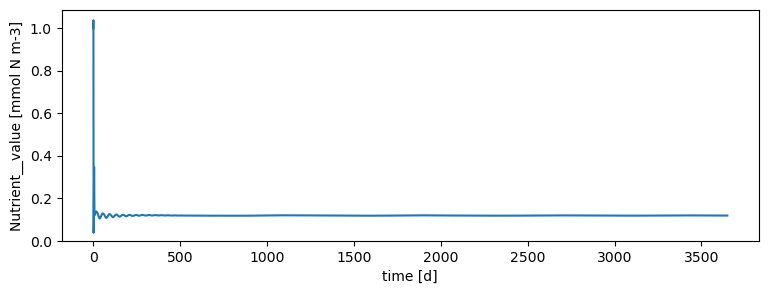

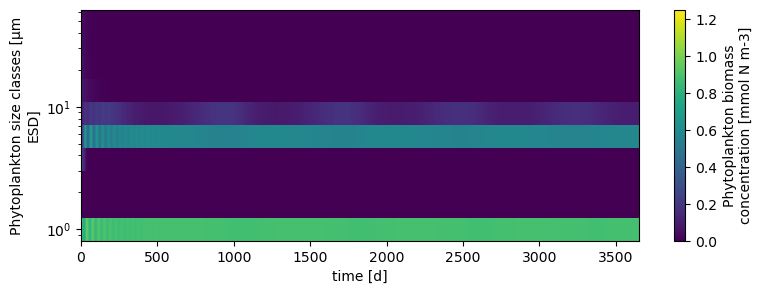

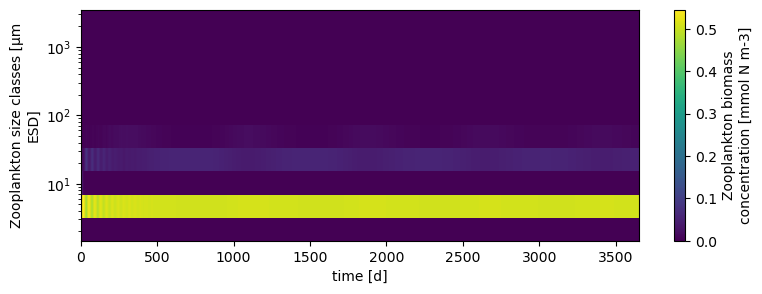

In [66]:
# let's get a quick overivew:

# plot nutrient:
model_out.Nutrient__value.plot(aspect=3, size=3, ylim=0)
# phytoplankton:
model_out.Phytoplankton__biomass.plot(yscale='log', aspect=3, size=3)
# zooplankton
model_out.Zooplankton__biomass.plot(yscale='log', aspect=3, size=3)

In [73]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

def plot_steady_state_diet(ds):
    """
    Plots the stacked diet composition (Phyto vs Zoo) for each Zoo size class,
    averaged over the last year (365 days) of the simulation.
    """
    
    # 1. Define the variables we actually want to plot
    # This avoids trying to average string variables like 'Core__solver_type'
    vars_to_use = ['GGE__assimilation_value', 'ZooGGE__assimilation_value']
    
    # 2. Select variables, slice time, and calculate mean
    ds_subset = ds[vars_to_use].isel(time=slice(-365, None)).mean(dim='time')
    
    # 3. Extract Data
    # P -> Z flow (averaged)
    flow_phyto = ds_subset['GGE__assimilation_value']
    
    # Z -> Z flow (averaged)
    # Sum over the prey dimension (zoo2) if it exists
    flow_zoo = ds_subset['ZooGGE__assimilation_value']

    # Extract sizes for labels from the original dataset coordinates
    zoo_sizes = ds.coords['zoo'].values
    x_indices = np.arange(len(zoo_sizes))
    
    # 4. Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot Phyto consumption (Bottom bar)
    ax.bar(x_indices, flow_phyto, label='Assimilation from Phyto', 
           color='#2ca02c', alpha=0.8) # Green
    
    # Plot Zoo consumption (Top bar, stacked on top of Phyto)
    ax.bar(x_indices, flow_zoo, bottom=flow_phyto, label='Assimilation from Zoo', 
           color='#d62728', alpha=0.8) # Red
    
    # Formatting
    ax.set_xlabel('Zooplankton Size Class (ESD)', fontsize=12)
    ax.set_ylabel('Mean Assimilation Rate (Units/day)', fontsize=12)
    ax.set_title('Diet Composition (Last Year Average)', fontsize=14)
    
    # Set X-ticks to be the Zoo sizes
    ax.set_xticks(x_indices)
    ax.set_xticklabels([f"{s:.1f}" for s in zoo_sizes], rotation=45)
    
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# Run the function
# plot_steady_state_diet(model_out)

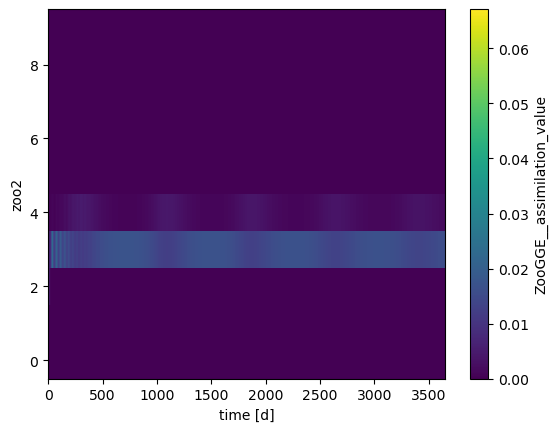

In [74]:
model_out['ZooGGE__assimilation_value'].plot(x='time')

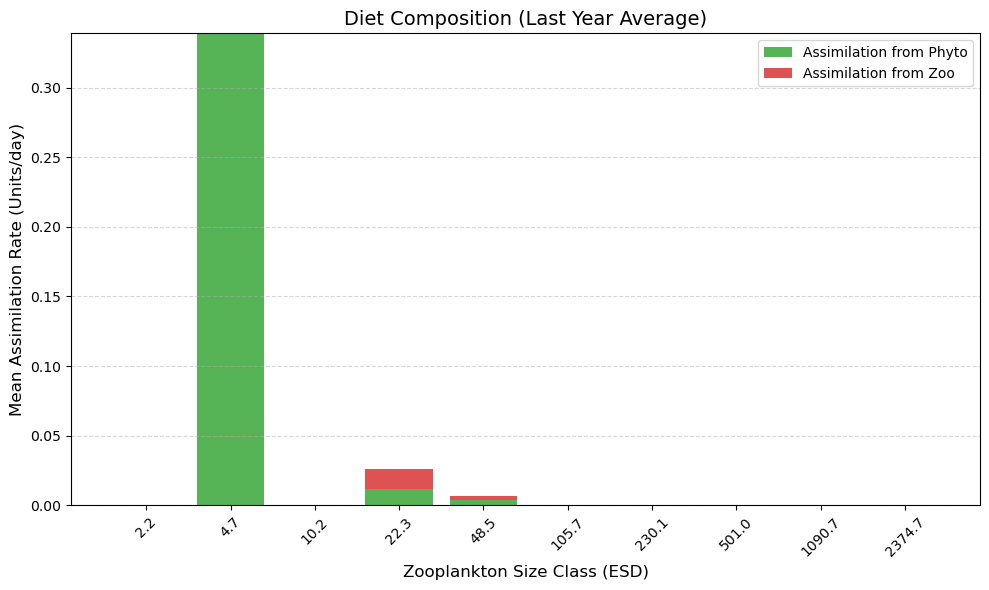

In [75]:
plot_steady_state_diet(model_out)